# Stochastic processes & wealth dynamics

## Topics for today

1.  Autoregressive processes: AR(1)
2.  Simulating wealth dynamics with IID income
3.  Simulating wealth dynamics with AR(1) income  

In [13]:
# Enable automatic reloading of external modules
%load_ext autoreload
%autoreload 2

***
## AR(1) process

-   One of the most widely used stochastic processes in economics and finance (linear & parsimonious)
-   Law of motion:
    $$
    \begin{aligned}
        x_{t+1} &= \mu + \rho x_t + \epsilon_{t+1} \\
        \epsilon_{t+1} &\stackrel{\text{iid}}{\sim} \mathcal{N}\left(0, \sigma^2\right)
    \end{aligned}
    $$

-   Parameters:

    -  $\mu$ controls the mean
    -  $\rho$ controls the autocorrelation
    -  $\sigma^2$ controls the variance of the error term $\epsilon_t$ (also called "innovation" or "shock")

-   Process is stationary if $\rho \in (-1, 1)$

-   Moments of the stationary distribution:

    -   Unconditional mean:
        $$
        \mathbb{E}[x_t] = \frac{\mu}{1-\rho}
        $$

    -   Unconditional variance:
        $$
        \text{Var}(x_t) = \frac{\sigma^2}{1-\rho^2}
        $$

    -   Stationary distribution:
        $$
        x_t \sim \mathcal{N}\left(\frac{\mu}{1-\rho}, \frac{\sigma^2}{1-\rho^2} \right)
        $$

***
### Simulating an AR(1) process

-   Simulate AR(1) for some given initial value $x_0$
-   Use [normal()](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html) to draw innovations $\epsilon_t$

In [16]:
import numpy as np

def simulate_ar1(x0, mu, rho, sigma, T, rng=None):
    """
    Simulate an AR(1) process for T periods, returning T+1 values including 
    the initial value.

    Parameters
    ----------
    x0 : float
        The initial value of the process.
    mu : float
        Intercept.
    rho : float
        The autoregressive parameter.
    sigma : float
        The standard deviation of the noise term.
    T : int
        The number of time periods to simulate.
    rng : Generator, optional
        Random number generator to use.

    Returns
    -------
    numpy.ndarray
        An array of length T+1 containing the simulated AR(1) process.
    """

    # TODO: Allocate array to store simulated values
    x = np.empty(T+1)

    # TODO: Set initial value
    x[0] = x0

    # TODO: Create RNG instance if none was provided
    if rng is None:
        rng = np.random.default_rng(seed=1234)

    # TODO: Draw random shocks (all at once)
    epsilon = rng.normal(loc=0, scale=sigma, size=T)

    # TODO: Use a loop to simulate the AR(1) process
    for t in range(T):
        x[t+1] = mu + rho * x[t] + epsilon[t]

    return x

- Simulate AR(1) for $x_0 = 0$, $\mu = 0$, $\rho = 0.9$, $\sigma = 0.1$ for $T=100$ periods

In [26]:
# RNG instance with seed
seed = 1234
rng = np.random.default_rng(seed=seed)

# TODO: Define AR(1) parameters and number of periods
x0 = 0

# Mean
mu = 0

# Autocorrelation rho
rho = .9

# Std.dev. of shocks
sigma = .1

# Simulate it for T = 100
T = 100

# TODO: Simulate AR(1) process
simulated_data = simulate_ar1(x0, mu, rho, sigma, T, rng)

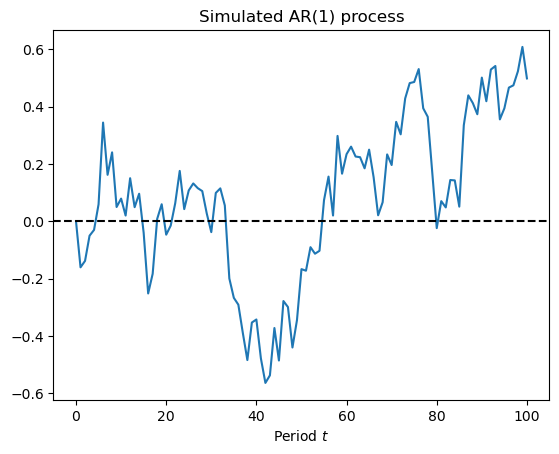

In [23]:
import matplotlib.pyplot as plt

plt.plot(simulated_data)
plt.title('Simulated AR(1) process')
plt.xlabel('Period $t$')
_ = plt.axhline(0, c='k', ls='--')

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Modify the above code to simulate the AR(1) from an initial value of <i>x<sub>0</sub> = 10</i>. Where does this simulated series converge to?
</div>
<span style="display: none;">YourTurnEnd</span>

In [24]:
seed = 1234
rng = np.random.default_rng(seed=seed)

x0 = 10
mu = 0
rho = .9
sigma = .1
T = 100

simulated_data = simulate_ar1(x0, mu, rho, sigma, T, rng)

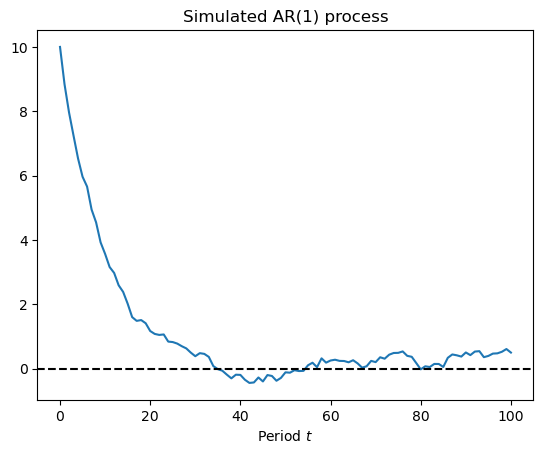

In [25]:
plt.plot(simulated_data)
plt.title('Simulated AR(1) process')
plt.xlabel('Period $t$')
_ = plt.axhline(0, c='k', ls='--')

- Simulate and plot $N=20$ different sequences using `simulate_ar1()`

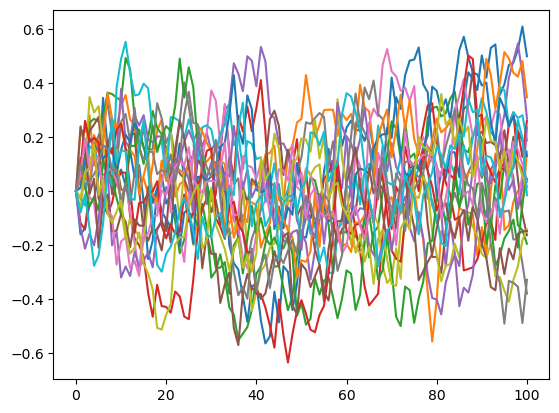

In [ ]:
# Simulate 20 different sequences
N = 20

# TODO: Create array to store simulated sequences
simulated_data20 = np.empty((N, T+1))

rng = np.random.default_rng(seed=1234)

# TODO: Simulate N sequences of the AR(1) process using a loop
for i in range(N):
    simulated_data20[i] = simulate_ar1(x0, mu, rho, sigma, T, rng)

# Can plot a matrix, but figure out if you have to transpose it by testing (might plot simulation n of N on x-axis when we want period t of T)
_ = plt.plot(simulated_data20.T)

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Let <i>μ = 1</i>, <i>ρ=0.95</i>, and <i>σ = 0.1</i>.
Using the function <tt>simulate_ar1()</tt>,
simulate 1,000,000 draws of <i>x<sub>t</sub></i> and verify that the unconditional mean and variance are close to the values given by the exact formulas above,
i.e., 
<i>E[x] = μ/(1-ρ)</i>
and
<i>Var(x) = σ<sup>2</sup> / (1-ρ<sup>2</sup>)</i>
.
</div>
<span style="display: none;">YourTurnEnd</span>

In [ ]:
x0 = 0  # Basically irrelevant when working with many periods (will affect variance more than mean)
mu = 1
rho = .95
sigma = .1

# Theoretical moments
mean_theoretical = mu / (1-rho)
var_theoretical = sigma**2/(1-rho**2)
print(f'Theoretical mean: {mean_theoretical:.3f}\nTheoretical variance: {var_theoretical:.3f}')

# Simulate 1_000_000 periods
T = 1_000_000
x = simulate_ar1(x0, mu, rho, sigma, T)

# Mean and variance of simulation
mean_sim = np.mean(x)
var_sim = np.var(x)

# Print results
print(f'Theoretical mean: {mean_theoretical:.3f}\nTheoretical variance: {var_theoretical:.3f}')
print(f'Simulated mean: {mean_sim:.3f}\nSimulated variance: {var_sim:.3f}')

Theoretical mean: 20.000
Theoretical variance: 0.103
Simulated mean: 20.002
Simulated variance: 0.107


***
## Wealth dynamics

### Savings rule

-   Household $i$'s wealth $a_t$ evolves according to
    $$
    a_{i,t+1} = R (a_{i,t} - c_{i,t}) + y_{i,t+1}
    $$

    where

    -   $c_{i,t}$ is consumption in period $t$
    -   $y_{i,t+1}$ is labor income in period $t+1$
    -   $R$ is the fixed (exogenous) interest rate

-   Assume *exogenous* rule-of-thumb savings rate $s$ :

    $$
    \begin{aligned}
        c_{i,t} &= (1-s)a_{i,t} \\
        a_{i,t+1} &= R \cdot s \cdot a_{i,t} + y_{i,t+1}
    \end{aligned}
    $$


***
### Wealth dynamics with stochastic IID income

-   Assume log income is IID normal (income in levels is *log-normal*):
    $$
    \log y_{i,t+1} \stackrel{\text{iid}}{\sim} \mathcal{N}\left(\mu_y, \sigma_y^2 \right)
    $$

    Parameters:

    -   $\mu_y$: mean of log income
    -   $\sigma_y^2$: variance of log income

-   **Goal**: Simulate wealth dynamics of a cross-section of households

***
#### Analytical results (to verify simulation results)

-   For a log-normal random variable $X$ we have:

    $$
    \begin{aligned}
        \log X \stackrel{\text{iid}}{\sim} \mathcal{N}\left(\mu, \sigma^2 \right)
        \quad\Longrightarrow\quad

        \begin{cases}
        \mathbb{E}[X] &= e^{ \mu + \frac{1}{2}\sigma^2} \\
        \text{Var}(X) &= \left( e^{\sigma^2} - 1 \right) e^{2 \mu + \sigma^2}
        \end{cases}
    \end{aligned}
    $$

-   Using this result, we can find the moments of the stationary distribution of wealth:

    -   Mean:
        $$
        \mathbb{E}[a_{i,t}] = \frac{\mathbb{E}[y_{i,t}]}{1 - Rs}
        = \frac{e^{\mu_y + \frac{1}{2}\sigma_y^2}}{1 - Rs}
        $$

    -   Variance:
        $$
        \text{Var}(a_{i,t}) = \frac{\text{Var}(y_{i,t})}{1-(Rs)^2} = 
        \frac{\left( e^{\sigma_y^2} - 1 \right) e^{2 \mu_y + \sigma_y^2}}{1-(Rs)^2}
        $$

-   Requires condition $R s < 1$ to hold!

***
#### Simulating the wealth distribution

| Symbol | Description | Value |
|--------|-------------|-------|
| $s$ | Savings rate | $0.75$ |
| $R$ | Gross return on investment | $1.1$ |
| $\sigma_y$ | Standard deviation of shocks to log income | $0.1$ |
| $\mu_y$ | Mean of log income | $-\frac{1}{2}\sigma_y^2$ |

- Define `Parameters` class
- Create an instance of the `Parameters` class

In [78]:
from dataclasses import dataclass

@dataclass
class Parameters:
    """
    Container to store model parameters
    """

    # TODO: Add model parameters here
    s: float = .75                      # Savings rate
    R: float = 1.1                      # Gross return on savings
    sigma_y: float = .5                 # Std.dev. of log income
    mu_y: float = - sigma_y**2 / 2      # Mean of log income

In [79]:
# Create an instance of the Parameters class
par = Parameters()

- Verify that the analytical unconditional mean of income is 1
- Compute the mean of the stationary wealth distribution.

In [80]:
# Mean of stationary INCOME distribution
y_mean = np.exp(par.mu_y + par.sigma_y**2/2)

# Mean of stationary ASSET distribution
a_mean = y_mean / (1 - par.s * par.R)

print(f'Mean income: {y_mean:.3f}')
print(f'Mean wealth: {a_mean:.3f}')

Mean income: 1.000
Mean wealth: 5.714


<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

<p>
Simulate 100,000 income draws of <i>y<sub>t</sub></i> and verify that the realizations have a mean of one, <i>E[y<sub>t</sub>] = 1</i>.
</p>
<p>
<i>Hint:</i> You need to draw a sample from the underlying 
<a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html">normal</a> 
distribution of <i>log y<sub>t</sub></i>
with parameters <i>μ<sub>y</sub></i> and <i>σ<sub>y</sub></i> and then apply the exponential function
<tt>np.exp()</tt>.
</p>
</div>
<span style="display: none;">YourTurnEnd</span>

In [81]:
N = 100_000
rng = np.random.default_rng(seed=1234)
# Draw log income from a normal
log_y = rng.normal(loc=par.mu_y, scale=par.sigma_y, size=N)

# Get income in levels
y = np.exp(log_y)

# Verify that income in levels is close to 1
mean_y = np.mean(y)

print(f'Average income in levels: {mean_y:.5f}')

Average income in levels: 1.00067


##### Implementation

*Steps:*

1. Draw all income realizations for all $N$ households and all $T$ periods and store them in a $T \times N$ array.
2. Set the initial assets for all households to the given value $a_0$.
3. Use the asset law-of-motion to simulate assets forward one period at a time.

In [82]:
def simulate_wealth_iid_income(par: Parameters, a0, T, N, rng=None):
    """
    Simulate the evolution of wealth over time when income is IID.

    The functions return T+1 values for each household, including the initial value.

    Parameters
    ----------
    par : Parameters
    a0 : float
        Initial wealth.
    T : int
        Number of time periods to simulate.
    N : int
        Number of households to simulate.
    rng : numpy.random.Generator, optional
        A random number generator instance.

    Returns
    -------
    a_sim : numpy.ndarray
        A (T+1, N) array where each column represents the simulated wealth path of a household.
    """

    # TODO: Create RNG instance if none was provided
    if rng is None:
        rng = np.random.default_rng(seed=1234)

    # TODO: Draw random income shocks for all households and periods
    # Draw all shocks at once, tuple size creates matrix
    log_y = rng.normal(loc=par.mu_y, scale=par.sigma_y, size=(T, N))
    y = np.exp(log_y)

    # TODO: Allocate array to store simulated wealth paths
    a_sim = np.empty((T+1, N))

    # TODO: Set initial wealth for all households
    a_sim[0] = a0

    # TODO: Use a loop to simulate the evolution of wealth for each period
    for t in range(T):
        # Compute next-period assets for all households at once
        a_sim[t+1] = par.R * par.s * a_sim[t] + y[t]  # confusing: t+1 in a_sim corresponds to t in y, because we only simulated T values of log_y (doesn't matter with IID)

    return a_sim

##### Simulating a small sample

In [83]:
# Initial wealth (identical for all households)
a0 = 1.0
# Number of households
N = 20
# Number of periods to simulate
T = 100

# Create RNG instance
rng = np.random.default_rng(seed=1234)

# TODO: Simulate wealth paths when income is IID
a_sim = simulate_wealth_iid_income(par, a0, T, N, rng)

# TODO: Compute average wealth in each period
a_sim_mean = np.mean(a_sim, axis=1)

- Plot the simulated wealth paths of 20 households

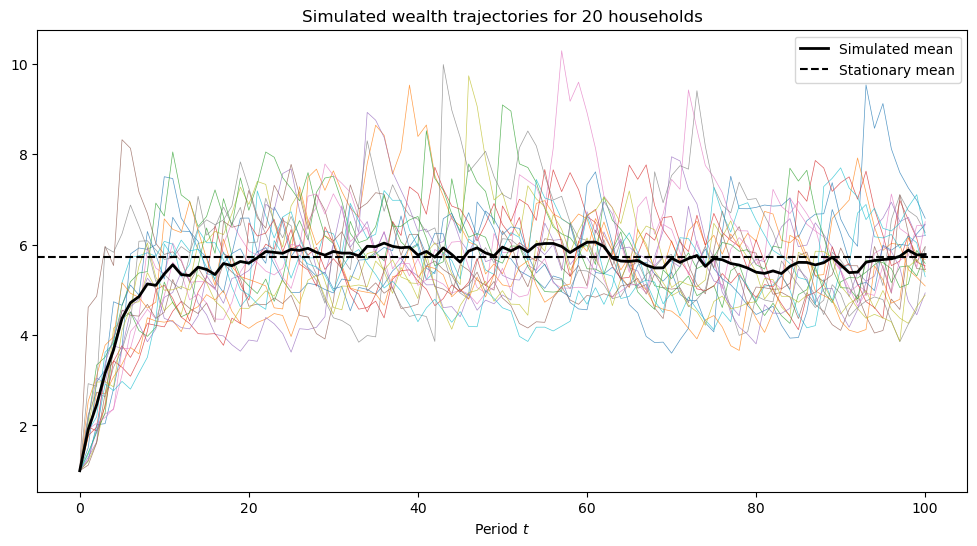

In [84]:
# TODO: Plot simulated wealth paths of 20 households
plt.figure(figsize=(12,6))
plt.plot(a_sim, lw=.5, alpha=.75)
plt.xlabel('Period $t$')
plt.title(f'Simulated wealth trajectories for {N} households')
# TODO: Plot simulated average wealth over time
plt.plot(a_sim_mean, c='k', lw=2, label='Simulated mean')
# TODO: Add horizontal line showing the mean of stationary wealth distribution
plt.axhline(a_mean, c='k', ls='--', lw=1.5, label='Stationary mean')
_ = plt.legend()

##### Simulating a large sample

In [85]:
# Number of households
N = 100_000
# Number of periods to simulate
T = 100

# Create RNG instance
rng = np.random.default_rng(seed=1234)

# TODO: Simulate wealth paths when income is IID
a_sim = simulate_wealth_iid_income(par, a0, T, N, rng)

***
##### Comparing simulated to analytical moments

-   Compute analytical moments using formulates from above
-   Compute moments of simulated data
-   Plot analytical vs. simulated cross-sectional mean and variance

In [ ]:
# TODO: Compute average wealth in each period
# a_sim_mean = ...

# TODO: Compute variance of wealth in each period
# a_sim_var = ...

In [ ]:
from lecture08_iid_income import compute_wealth_mean, compute_wealth_var

# Compute analytical mean and variance
a_mean_exact = compute_wealth_mean(par)
a_var_exact = compute_wealth_var(par)

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

# Plot simulated vs. analytical mean
ax1.axhline(a_mean_exact, color='black', ls='--', lw=1, label='Exact')
ax1.plot(a_sim_mean, lw=1, label='Simulated')
ax1.set_xlabel('Period')
ax1.set_title('Cross-sectional mean of wealth')
ax1.legend(loc='lower right')

# Plot simulated vs. analytical variance
ax2.axhline(a_var_exact, color='black', ls='--', lw=1, label='Exact')
ax2.plot(a_sim_var, lw=1, label='Simulated')
ax2.set_title('Cross-sectional variance of wealth')
ax2.set_xlabel('Period')
ax2.legend(loc='lower right')

***
##### Measuring wealth inequality

-   Use Gini coefficient to measure wealth inequality in the simulated economy
-   Implement `gini()` function using [formula for sorted arrays](https://en.wikipedia.org/wiki/Gini_coefficient#Alternative_expressions):

    $$
    G_t = \frac{2}{N} \frac{\sum_{i=1}^N i \cdot a_{i,t}}%
        {\sum_{i=1}^N a_{i,t}}
        - \frac{N+1}{N}
    $$

-   Use [np.sort()](https://numpy.org/doc/stable/reference/generated/numpy.sort.html) to sort NumPy array

In [86]:
def gini(x):
    """
    Compute the Gini coefficient of an array.

    Parameters
    ----------
    x : numpy.ndarray
        An array of income, wealth, etc.

    Returns
    -------
    float
        The Gini coefficient.
    """

    N = len(x)

    # TODO: Sort the input array
    x = np.sort(x)

    # TODO: Compute the Gini coefficient using the formula
    # First term, pre-allocated ii (faster than loop, but uses more memory)
    ii = np.arange(1, N+1)
    num = np.sum(ii * x)
    denom = np.sum(x)

    G = 2 / N * num / denom - (N+1) / N

    return G

- Use `gini()` to compute the Gini in the last simulated period

In [87]:
g_last = gini(a_sim[-1])
print(f'Gini in the last period: {g_last:.5f}')

Gini in the last period: 0.09156


<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Change the parameter <i>σ<sub>y</sub></i> governing the volatility of income to <i>σ<sub>y</sub> = 0.5</i>
and rerun the code for the whole current section. What happens to average wealth in the economy and to the Gini coefficient?
</div>
<span style="display: none;">YourTurnEnd</span>

Pre: $0.01755$
Post: $0.09156$

With IID income, we won't find wealth inequality

***
### Wealth dynamics with persistent income

-   Assume now that household $i$'s income follows an AR(1) in logs:
$$
\begin{aligned}
\log y_{i,t+1} &= \mu_y + \rho \log y_{i,t} + \epsilon_{i,t+1} \\
\epsilon_{i,t+1} &\stackrel{\text{iid}}{\sim} \mathcal{N}\left(0, \sigma_{\epsilon}^2 \right)
\end{aligned}
$$


***
#### Analytical results (to verify simulation results)

-   **Income:**
    -   Stationary distribution of log income:

        $$
        \log y_{i,t} \sim \mathcal{N}\left(\frac{\mu_y}{1-\rho}, \frac{\sigma_{\epsilon}^2}{1-\rho^2} \right)
        $$

    -   Mean of stationary income distribution:
        $$
        \mathbb{E}[y_{i,t}] = \exp\left\{\frac{\mu_y}{1-\rho} + \frac{1}{2} \frac{\sigma_{\epsilon}^2}{1-\rho^2}\right\}
        $$

-   **Assets:**
    -   Mean of stationary asset distribution:

        $$
        \mathbb{E}[a_{i,t}] = \frac{\mathbb{E}[y_{i,t}]}{1 - Rs}
        $$

    -   Variance? No closed-form expression available.

***
#### Simulating the wealth distribution

| Symbol | Description | Value |
|--------|-------------|-------|
| $s$ | Savings rate | $0.75$ |
| $R$ | Gross return on investment | $1.1$ |
| $\rho$ | Persistence of log income | $0.95$ |
| $\sigma_{\epsilon}$ | Standard deviation of shocks to log income | $0.1$ |
| $\mu_y$ | Mean of log income | $-\frac{1}{2}\frac{\sigma_{\epsilon}^2}{1+\rho}$ |

In [88]:
from dataclasses import dataclass

@dataclass
class Parameters:
    """
    Container to store model parameters
    """

    # TODO: Add model parameters here
    s: float = .75
    R: float = 1.1
    rho: float = .95
    sigma_e: float = .1
    mu_y: float = -sigma_e**2 / (1+rho) / 2


In [89]:
# Create an instance of the Parameters class
par = Parameters()

-   Compute analytical mean of income and assets

In [90]:
# Mean of stationary INCOME distribution 
y_mean = np.exp(par.mu_y/(1-par.rho) + par.sigma_e**2/2/(1-par.rho**2))

# Mean of stationary ASSET distribution
a_mean = y_mean / (1 - par.s * par.R)

print(f'Mean income: {y_mean:.3f}')
print(f'Mean wealth: {a_mean:.3f}')

Mean income: 1.000
Mean wealth: 5.714


<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Simulate a time series of 10,000,000 income draws <i>y<sub>t</sub></i> and verify that the realizations have a mean of one.
Use the <tt>simulate_ar1()</tt> function we wrote earlier for this task.

</div>
<span style="display: none;">YourTurnEnd</span>

In [ ]:
N = 10_000_000
...

##### Implementation

*Steps:*

1. Draw all AR(1) shock realizations for all $N$ households and all $T$ periods and store them in a $T \times N$ array.
2. Assume that all households start with the same income which corresponds to the unconditional mean of the AR(1).
3. Set the initial assets for all households to the given value $a_0$.
4. Use the AR(1) law of motion to simulate next-period income given current income.
5. Use the asset law of motion to simulate next-period assets.

In [91]:
def simulate_wealth_ar1_income(par: Parameters, a0, T, N, rng=None):
    """
    Simulate the evolution of wealth over time if income follows an AR(1).

    The functions return T+1 values for each household, including the initial value.

    Parameters
    ----------
    par : Parameters
    a0 : float
        Initial wealth.
    T : int
        Number of time periods to simulate.
    N : int
        Number of households to simulate.
    rng : numpy.random.Generator, optional
        A random number generator instance.

    Returns
    -------
    a_sim : numpy.ndarray
        A (T+1, N) array where each column represents the simulated wealth path of a household.
    """

    # TODO: Create RNG instance if none was provided
    if rng is None:
        rng = np.random.default_rng(seed=1234)

    # TODO: Draw random income SHOCKS for all households and periods
    epsilon = rng.normal(loc=0, scale=par.sigma_e, size=(T, N))

    # TODO: Allocate array to store simulated income (one period at a time)
    # Assume that all households start at mean log income
    mean_log_y = par.mu_y / (1 - par.rho)
    log_y = np.full(N, fill_value=mean_log_y)

    # TODO: Allocate array to store simulated wealth paths
    a_sim = np.empty((T+1, N))

    # TODO: Set initial wealth for all households
    a_sim[0] = a0

    # TODO: Use a loop to simulate the evolution of income and wealth for each period
    for t in range(T):
        # Compute next-period income
        log_y = par.mu_y + par.rho * log_y + epsilon[t]

        # Compute next-period wealth
        a_sim[t+1] = par.R * par.s * a_sim[t] + np.exp(log_y)


    return a_sim

##### Simulating a small sample

In [92]:
# Initial wealth (identical for all households)
a0 = 1.0
# Number of households
N = 20
# Number of periods to simulate
T = 100

# Create RNG instance
rng = np.random.default_rng(seed=1234)

# TODO: Simulate wealth paths when income follows an AR(1) process
a_sim = simulate_wealth_ar1_income(par, a0, T, N, rng)

# TODO: Compute average wealth in each period
a_sim_mean = np.mean(a_sim, axis=1)

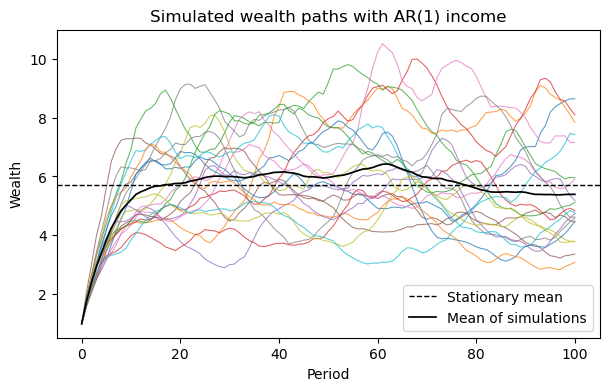

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(a_sim, alpha=0.75, lw=0.75)
plt.xlabel('Period')
plt.ylabel('Wealth')
plt.title('Simulated wealth paths with AR(1) income')
# Add unconditional mean of wealth distribution
plt.axhline(a_mean, color='black', ls='--', lw=1, label='Stationary mean')
# Add average of simulated wealth paths
plt.plot(a_sim_mean, color='black', ls='-', lw=1.25, label='Mean of simulations')
plt.legend(loc='lower right')

##### Simulating a large sample

In [95]:
# Number of households
N = 100_000
# Number of periods to simulate
T = 100

# Create RNG instance
rng = np.random.default_rng(seed=1234)

# TODO: Simulate wealth paths when income follows an AR(1) process
a_sim = simulate_wealth_ar1_income(par, a0, T, N, rng)

***
##### Comparing simulated to analytical moments

-   Compute analytical moments using formulates from above
-   Compute moments of simulated data
-   Plot analytical vs. simulated cross-sectional mean and variance

In [ ]:
from lecture08_ar1_income import compute_wealth_mean

# Compute analytical mean
a_mean_exact = compute_wealth_mean(par)

- Compute cross-sectional mean and variance of simulated wealth trajectories

In [ ]:
# TODO: Compute mean of simulated wealth trajectories
# a_sim_mean = ...

# TODO: Compute cross-sectional variance of simulated wealth trajectories
# a_sim_var = ...

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

# Plot simulated vs. analytical mean
ax1.axhline(a_mean_exact, color='black', ls='--', lw=1, label='Exact')
ax1.plot(a_sim_mean, lw=1, label='Simulated')
ax1.set_xlabel('Period')
ax1.set_title('Cross-sectional mean of wealth')
ax1.legend(loc='lower right')

# Plot simulated variance
ax2.plot(a_sim_var, lw=1, label='Simulated')
ax2.set_title('Cross-sectional variance of wealth')
ax2.set_xlabel('Period')
ax2.legend(loc='lower right')

***
##### Measuring wealth inequality

- Compute Gini coefficient of wealth distribution in the last simulated period

In [96]:
g_ar1 = gini(a_sim[-1])
print(f'Gini with AR(1) income: {g_ar1:.5f}')

Gini with AR(1) income: 0.15979


<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Change the parameter <i>ρ</i> governing the persistence of income to
<ol>
    <li><i>ρ=0.5</i></li>
    <li><i>ρ=0.99</i></li>
</ol>
and rerun the code for the whole current section. What happens to average wealth in the economy and to the Gini coefficient?
</div>
<span style="display: none;">YourTurnEnd</span>